(phillips_escaping_nash)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 逃离纳什通胀

```{index} single: Phillips Curve; Escaping Nash Inflation
```

```{contents} Contents
:depth: 2
```

## 概览

> 如果一个不太可能发生的事件发生了，它极有可能是以最可能的方式发生的。
>
> —— 迈克尔·哈里森

本讲座是 {doc}`phillips_learning` 的分析性完成篇。

它遵循 {cite}`ChoWilliamsSargent2002`（CWS），该文将 {cite}`Sargent1999` 第 8 章中*模拟*出的逃逸动态转化为一种*确定性刻画*。

在 {doc}`phillips_learning` 中，我们观察到一个恒定增益的政府反复地逃离纳什自我确认均衡，并在拉姆齐结果附近长时间停留——但我们只是通过模拟对这些逃逸做了非正式的描述。

CWS 表明，这些逃逸受它们自身的常微分方程支配，该方程由**大偏差理论**得出。

由此出现的图景包含两个确定性部分：

* **均值动态**：一个把政府信念拉*向*自我确认均衡的常微分方程；以及
* **逃逸动态**：第二个常微分方程——由一个"最可能的不太可能"的冲击序列驱动——将信念推*离*自我确认均衡，朝支持拉姆齐结果的信念方向移动。

一个引人注目的发现是，逃逸存在一条*主导路径*：在发生逃逸的条件下，政府的信念会沿着一条几乎确定的路线演变，沿途它暂时习得了自然率假说的某个版本，并削减了通货膨胀。

本讲座是 {doc}`phillips_learning` 的技术延伸；下一讲 {doc}`phillips_priors` 在此基础上，探讨政府关于参数漂移的*先验*如何重塑均值动态与这些逃逸动态。

我们使用便于分析处理的**静态**模型。

让我们从导入相关模块开始：

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

## 模型

真实经济是 {cite}`KydlandPrescott1977` 的自然率模型，

```{math}
:label: en_truth

U_n = u - \theta(\pi_n - \hat x_n) + \sigma_1 W_{1n},
\qquad
\pi_n = x_n + \sigma_2 W_{2n},
\qquad
\hat x_n = x_n,
```

其中 $\theta, u > 0$，且 $W_n = (W_{1n}, W_{2n})^\top$ 为独立同分布的标准高斯变量。

政府并不知道 {eq}`en_truth`。

在静态模型中，它通过将失业率对通货膨胀和一个常数项做回归，拟合一条非预期性菲利普斯曲线，

```{math}
:label: en_belief

U_n = \gamma_1 \pi_n + \gamma_{-1} + \eta_n ,
```

信念为 $\gamma = (\gamma_1, \gamma_{-1})$（斜率与截距），并将 $\eta_n$ 视为外生的。

```{note}
这里斜率在前，回归量为 $\Phi = (\pi, 1)$，与 {cite}`ChoWilliamsSargent2002` 以及 {doc}`phillips_self_confirming` 中 $\gamma_1, \gamma_{-1}$ 的约定保持一致。

{doc}`phillips_priors` 研究了同一模型，但截距在前；有关这种转换请参阅该处的提示。
```

在相信 {eq}`en_belief` 的前提下，政府求解 {doc}`菲尔普斯问题 <phillips_adaptive>`，其静态最优反应将通货膨胀设定为常数

```{math}
:label: en_bestresp

x(\gamma) = -\frac{\gamma_{-1}\, \gamma_1}{1 + \gamma_1^2} .
```

按照 CWS 的说法，三种信念值得单独命名：

* **信念 1（纳什）：** $\gamma_1 = -\theta$，截距使 $x = \theta u$ —— 这正是 {cite}`KydlandPrescott1977` 的时间一致结果。
* **信念 2（拉姆齐）：** $\gamma_1 = 0$，此时政府认为不存在权衡取舍，设定 $x = 0$。
* **信念 3（归纳）：** 通货膨胀系数之和为零，对于一个有耐心的政府，这同样会使通货膨胀趋于 $0$。

In [2]:
class EscapeModel:
    "CWS 2002 static model. γ = (γ₁ slope, γ₋₁ intercept), regressors Φ = (π, 1)."

    def __init__(self, θ=1.0, u=5.0, σ1=0.3, σ2=0.3):
        self.θ, self.u, self.σ1, self.σ2 = θ, u, σ1, σ2

    def x(self, γ):
        γ1, γm1 = γ
        return -γm1 * γ1 / (1 + γ1**2)

    def M(self, γ):
        "E[ΦΦ'] with Φ = (π, 1)."
        x = self.x(γ)
        return np.array([[x**2 + self.σ2**2, x], [x, 1.0]])

    def g_bar(self, γ):
        "Mean-dynamics forcing E[Φ(U − Φ'γ)] = M(T(γ) − γ)."
        x = self.x(γ)
        E_ΦU = np.array([x * self.u - self.θ * self.σ2**2, self.u])
        return E_ΦU - self.M(γ) @ γ

## 自我确认均衡

自我确认均衡是一种能够自我复制的信念：政府依据 $\gamma$ 采取行动所生成的数据上，{eq}`en_belief` 的总体回归系数等于 $\gamma$ 本身。

将这些总体系数记为 $T(\gamma)$，CWS 证明

$$
\bar g(\gamma) \equiv \mathbb{E}\left[\Phi(U - \Phi^\top \gamma)\right] = \bar M \left(T(\gamma) - \gamma\right),
$$

因此自我确认均衡解出 $\bar g(\gamma) = 0$。

对于静态模型，均衡是直线 $\gamma_1 = -\theta$ 与抛物线 $\gamma_{-1} = u(1 + \gamma_1^2)$ 的交点——一个唯一点，它支持 {doc}`phillips_credibility` 中的纳什结果。

它与 {doc}`phillips_self_confirming` 中构造的自我确认均衡相同，此处以静态（常数加斜率）特例的形式给出，{doc}`phillips_priors` 中同样使用这一形式。

In [3]:
model = EscapeModel(θ=1.0, u=5.0, σ1=0.3, σ2=0.3)
γ_sce = np.array([-model.θ, model.u * (1 + model.θ**2)])

print(f"self-confirming beliefs γ = {γ_sce}  (slope -θ, intercept u(1+θ²))")
print(f"self-confirming inflation x = {model.x(γ_sce):.2f}  (= Nash = θu)")
print(f"check g_bar = {model.g_bar(γ_sce)}")

self-confirming beliefs γ = [-1. 10.]  (slope -θ, intercept u(1+θ²))
self-confirming inflation x = 5.00  (= Nash = θu)
check g_bar = [0. 0.]


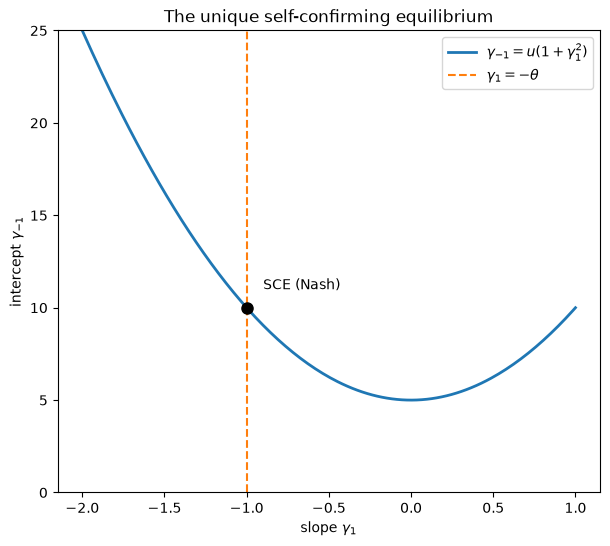

In [4]:
γ1_grid = np.linspace(-2, 1, 200)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(γ1_grid, model.u * (1 + γ1_grid**2), label=r'$\gamma_{-1} = u(1+\gamma_1^2)$', lw=2)
ax.axvline(-model.θ, color='C1', ls='--', label=r'$\gamma_1 = -\theta$')
ax.plot(γ_sce[0], γ_sce[1], 'ko', ms=8)
ax.annotate('SCE (Nash)', γ_sce, (γ_sce[0] + 0.1, γ_sce[1] + 1))
ax.set_xlabel(r'slope $\gamma_1$')
ax.set_ylabel(r'intercept $\gamma_{-1}$')
ax.set_ylim(0, 25)
ax.legend()
ax.set_title('The unique self-confirming equilibrium')
plt.show()

## 适应性与均值动态

我们令政府具有适应性：每期它都通过恒定增益递归最小二乘法更新 $\gamma$，并依据当前的估计值采取行动——这是 {cite}`Kreps1998` 意义上的**预期效用**模型。

关于最小二乘学习的文献（{cite}`MarcetSargent1989`、{cite}`Woodford1990`、{cite}`EvansHonkapohja2001`）表明，当增益 $\varepsilon \to 0$ 时，信念可以由**均值动态**常微分方程近似：

```{math}
:label: en_mean

\dot\gamma = R^{-1} \bar g(\gamma),
\qquad
\dot R = \bar M(\gamma) - R .
```

{eq}`en_mean` 的一个静止点即为一个自我确认均衡，CWS 证明该常微分方程围绕它是*全局稳定*的。

因此，仅在均值动态作用下，适应性政府会被吸引到纳什通货膨胀水平。

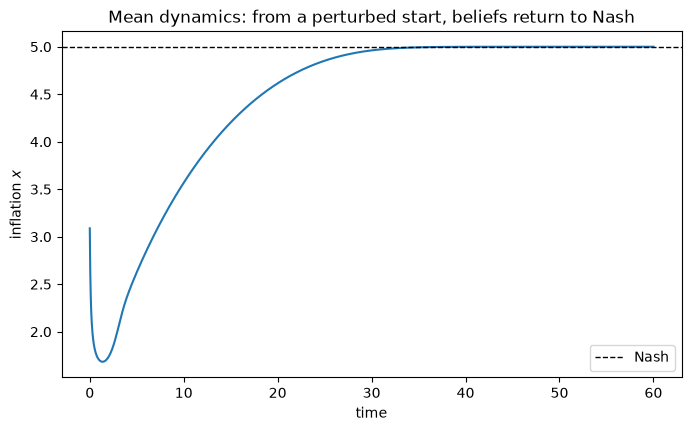

In [5]:
def mean_ode(t, z, model):
    γ, R = z[:2], z[2:].reshape(2, 2)
    return np.concatenate([np.linalg.inv(R) @ model.g_bar(γ),
                           (model.M(γ) - R).ravel()])

z0 = np.concatenate([γ_sce + np.array([0.4, -3.0]), model.M(γ_sce).ravel()])
sol = solve_ivp(lambda t, z: mean_ode(t, z, model), [0, 60], z0,
                max_step=0.1, rtol=1e-9, atol=1e-11)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sol.t, -sol.y[1] * sol.y[0] / (1 + sol.y[0]**2))
ax.axhline(model.θ * model.u, color='k', ls='--', lw=1, label='Nash')
ax.set_xlabel('time')
ax.set_ylabel('inflation $x$')
ax.set_title('Mean dynamics: from a perturbed start, beliefs return to Nash')
ax.legend()
plt.show()

均值动态本身无法解释 {doc}`phillips_learning` 中模拟所显示的反复出现的低通胀访问现象。

要解释这一点，我们需要第二种力量。

## 作为控制问题的逃逸动态

尽管当 $\varepsilon \to 0$ 时噪声的影响会消失，但对于固定的正增益，*罕见*的冲击序列可以将信念推离自我确认均衡很远。

大偏差理论刻画了这种罕见事件*最可能*的形式。

对于一条候选信念路径 $\gamma(\cdot)$，可以定义最小二乘创新的对数矩生成（H-）泛函，其勒让德变换 $L$，以及一个**行动泛函** $S(T, \gamma) = \int_0^T L\,ds$，用以衡量该路径的"代价"——即它有多不可能。

**主导逃逸路径**在离开 $\bar\gamma$ 的一个邻域 $G$ 的约束下最小化行动值。

借鉴 {cite}`Williams2019`，CWS 将其归纳为一个简洁的控制问题：H-泛函变为具有归一化矩阵 $Q$（由李雅普诺夫方程得到的四阶矩矩阵）的二次形式，逃逸路径求解

```{math}
:label: en_control

\bar S = \inf_{v(\cdot),\, T} \; \frac12 \int_0^T v(s)^\top Q(\gamma(s), R(s))^{-1} v(s)\, ds
```

约束条件为*受扰动的*均值动态

```{math}
:label: en_perturbed

\dot\gamma = R^{-1}\bar g(\gamma) + v,
\qquad
\dot R = \bar M(\gamma) - R,
\qquad
\gamma(0) = \bar\gamma, \; \gamma(T) \notin G .
```

可以将 {eq}`en_control` 理解为一个最小二乘问题：$v$ 是均值动态要实现逃逸所需的额外"强制项"，$Q$ 起协方差矩阵的作用，代价最低的强制项即是最可能出现的异常冲击序列。

其两个推论（他们的定理 5.3）将该控制问题与随机模型联系起来：

* 在一个有界区间上发生逃逸的概率约为 $\exp(-\bar S/\varepsilon)$，因此**逃逸之间的平均时间**约为 $\exp(\bar S/\varepsilon)$；且
* 在发生逃逸的条件下，信念以趋近于一的概率沿主导逃逸路径演变。

逃逸动态与均值动态一样，都是*确定性*的。

## 主导逃逸路径

对于具有二项冲击的静态模型，CWS 以封闭形式求解了该控制问题（其第 7 节）。

逃逸强制项异常简单：

```{math}
:label: en_force

v = R^{-1} \begin{bmatrix} \sigma_1 \sigma_2 \\ 0 \end{bmatrix} ,
```

因此主导逃逸路径求解

```{math}
:label: en_escape

\dot\gamma = R^{-1}\left( \bar g(\gamma) + \begin{bmatrix} \sigma_1 \sigma_2 \\ 0 \end{bmatrix} \right),
\qquad
\dot R = \bar M(\gamma) - R .
```

让我们从自我确认均衡出发对 {eq}`en_escape` 进行积分，直到信念离开一个半径为 5 的圆。

In [6]:
def escape_ode(t, z, model):
    γ, R = z[:2], z[2:].reshape(2, 2)
    force = np.array([model.σ1 * model.σ2, 0.0])
    return np.concatenate([np.linalg.inv(R) @ (model.g_bar(γ) + force),
                           (model.M(γ) - R).ravel()])

def left_circle(t, z):
    "Terminal event: beliefs leave the radius-5 circle around the SCE."
    return 5.0 - np.linalg.norm(z[:2] - γ_sce)
left_circle.terminal = True
left_circle.direction = -1

z0 = np.concatenate([γ_sce, model.M(γ_sce).ravel()])
esc = solve_ivp(lambda t, z: escape_ode(t, z, model), [0, 200], z0,
                events=left_circle, max_step=0.02, rtol=1e-9, atol=1e-11)

slope, intercept = esc.y[0], esc.y[1]
infl = -intercept * slope / (1 + slope**2)

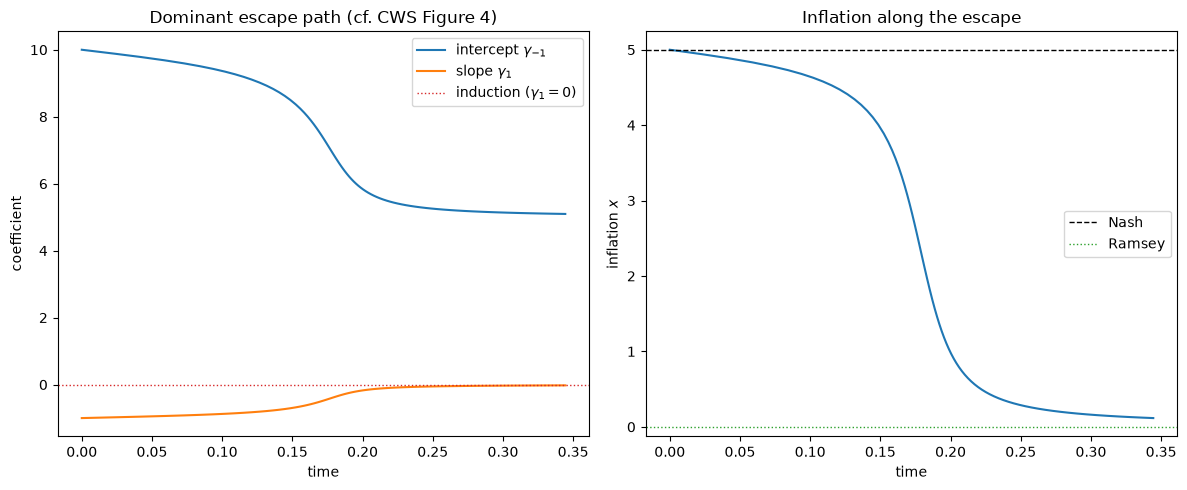

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(esc.t, intercept, label='intercept $\\gamma_{-1}$')
axes[0].plot(esc.t, slope, label='slope $\\gamma_1$')
axes[0].axhline(0, color='C3', ls=':', lw=1, label='induction ($\\gamma_1 = 0$)')
axes[0].set_xlabel('time')
axes[0].set_ylabel('coefficient')
axes[0].set_title('Dominant escape path (cf. CWS Figure 4)')
axes[0].legend()

axes[1].plot(esc.t, infl)
axes[1].axhline(model.θ * model.u, color='k', ls='--', lw=1, label='Nash')
axes[1].axhline(0, color='C2', ls=':', lw=1, label='Ramsey')
axes[1].set_xlabel('time')
axes[1].set_ylabel('inflation $x$')
axes[1].set_title('Inflation along the escape')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
print(f"slope     : {slope[0]:.2f} → {slope[-1]:.3f}   (induction hypothesis at 0)")
print(f"intercept : {intercept[0]:.1f} → {intercept[-1]:.1f}")
print(f"inflation : {infl[0]:.2f} → {infl[-1]:.2f}   (Nash {model.θ*model.u:.0f} → Ramsey 0)")

slope     : -1.00 → -0.023   (induction hypothesis at 0)
intercept : 10.0 → 5.1
inflation : 5.00 → 0.12   (Nash 5 → Ramsey 0)


沿着主导逃逸路径，斜率从其自我确认值 $-1$ 上升到接近零——即**归纳假说**——通货膨胀则从纳什水平下降到接近拉姆齐水平。

这正是我们在 {doc}`phillips_learning` 中通过模拟看到的那种暂时性稳定化，现在被推导为一条确定性路径：政府偶然生成了足够多的通货膨胀*实验*，从而发现了自然率假说的一个足够好的版本，并据此采取行动。

## 四条常微分方程的竞速

逃逸强制项 {eq}`en_force` 从何而来？

对于二项冲击 $W_{in} \in \{-1, +1\}$，任意一期实现的冲击组合都落在四组之一。

CWS 证明，最可能的逃逸会*反复*使用相同的异常组合，因此存在四条候选逃逸常微分方程——每种组合对应一条——而主导逃逸即为最快到达边界的那一条。

让我们计算每个候选路径在自我确认均衡处的瞬时速度。

In [9]:
R0 = model.M(γ_sce)
R0_inv = np.linalg.inv(R0)
σ1σ2 = model.σ1 * model.σ2

x_sce = model.x(γ_sce)

# each pair of shock realizations induces its own escape forcing
candidates = {
    "{(1,1),(-1,-1)}  → Ramsey":   np.array([σ1σ2, 0.0]),
    "{(1,-1),(-1,1)}  → higher π": np.array([-σ1σ2, 0.0]),
    "{(1,1),(1,-1)}":              np.array([x_sce * model.σ1, model.σ1]),
    "{(-1,1),(-1,-1)}":            np.array([-x_sce * model.σ1, -model.σ1]),
}

for name, force in candidates.items():
    v = R0_inv @ force                     # belief velocity along this candidate
    print(f"  {name:28s}  |velocity| = {np.linalg.norm(v):.3f}")

  {(1,1),(-1,-1)}  → Ramsey     |velocity| = 5.099
  {(1,-1),(-1,1)}  → higher π   |velocity| = 5.099
  {(1,1),(1,-1)}                |velocity| = 0.300
  {(-1,1),(-1,-1)}              |velocity| = 0.300


组合 $\{(1,1), (-1,-1)\}$ 产生的速度远大于最后两个组合，且其方向指*向*拉姆齐（斜率上升、截距下降）。

其镜像组合 $\{(1,-1),(-1,1)\}$ 具有相同的速率，但方向错误——指向*更高*的通货膨胀——而在那个方向上均值动态会与之对抗，很快将其拉回。

因此这场竞速的胜者是朝向拉姆齐方向的路径，它所诱导出的逃逸强制项正是 {eq}`en_force` 中的 $R^{-1}(\sigma_1\sigma_2, 0)^\top$。

## 均值动态强化逃逸

为什么朝向拉姆齐的逃逸能够成功，而其镜像却失败了？

在自我确认均衡附近，均值动态指*向*该均衡，对抗任何逃逸。

但 CWS（其图 8-9）表明，一旦信念沿朝向拉姆齐的方向移动了一小段距离，均值动态本身就开始指*向*拉姆齐，从而强化了逃逸。

我们可以通过绘制信念空间中的均值动态向量场来观察这一点。

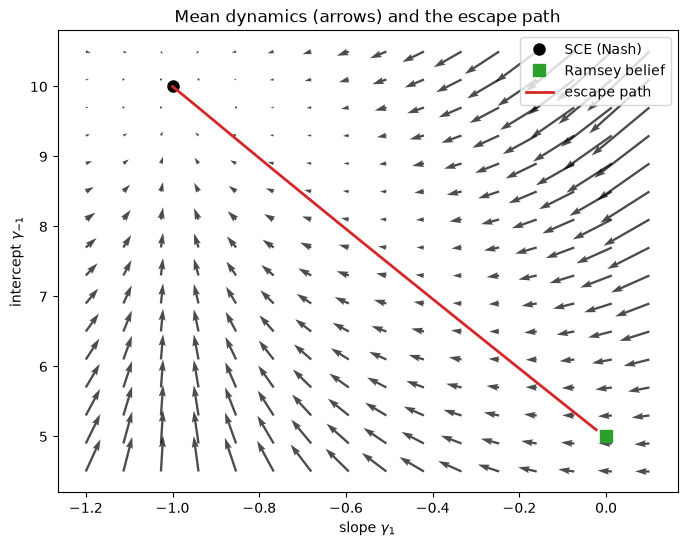

In [10]:
gs = np.linspace(-1.2, 0.1, 16)      # slope
gi = np.linspace(4.5, 10.5, 16)      # intercept
GS, GI = np.meshgrid(gs, gi)
DS, DI = np.zeros_like(GS), np.zeros_like(GI)

for i in range(GS.shape[0]):
    for j in range(GS.shape[1]):
        γ = np.array([GS[i, j], GI[i, j]])
        d = np.linalg.inv(model.M(γ)) @ model.g_bar(γ)
        DS[i, j], DI[i, j] = d

fig, ax = plt.subplots(figsize=(8, 6))
ax.quiver(GS, GI, DS, DI, angles='xy', alpha=0.7)
ax.plot(*γ_sce, 'ko', ms=8, label='SCE (Nash)')
ax.plot(0, model.u, 'C2s', ms=8, label='Ramsey belief')
ax.plot(slope, intercept, 'C3', lw=2, label='escape path')
ax.set_xlabel(r'slope $\gamma_1$')
ax.set_ylabel(r'intercept $\gamma_{-1}$')
ax.set_title('Mean dynamics (arrows) and the escape path')
ax.legend()
plt.show()

在自我确认均衡附近，箭头将信念推回纳什水平，但离开该均衡后——沿着逃逸路径——箭头则朝拉姆齐信念方向扫动。

逃逸动态只需要*启动*这一背离过程；均值动态负责完成剩余的工作。

正是在这个意义上，均值动态描绘出一条*迂回*的路线：被逃逸路径推离均衡后，系统会在拉姆齐附近停留一段时间，然后残留的短期菲利普斯曲线才被重新发现，均值动态最终将信念带回纳什水平。

## 试验陷阱

这种逃逸具有一种令人信服的行为解释。

在其近似模型内部，政府只有当通货膨胀存在足够的*离散度*时，才能检测到自然率假说。

但在自我确认均衡内，政府设定了一个恒定的系统性通货膨胀率，因此不会产生这种离散度——它被困在一个**试验陷阱**中。

只有一段异常的冲击序列，才会使政府充分改变通货膨胀，从而使其估计的菲利普斯曲线变得更陡；一条更陡峭的感知曲线（通过最优反应）会引导它削减通货膨胀，这又会产生进一步的有影响力的观测值，使曲线进一步变陡。

这种自我强化的过程会在感知的菲利普斯曲线变得垂直时——即归纳假说——停止，通货膨胀接近拉姆齐水平。

系统无法永远停留在那里：事实上*确实*存在一条短期菲利普斯曲线，政府最终会重新发现它，从而重新点燃将其带回纳什水平的均值动态。

## 逃逸频率与模型丰富度

被最小化的行动值 $\bar S$ 决定了逃逸发生的频繁程度：平均逃逸时间以 $\exp(\bar S/\varepsilon)$ 的速度增长。

CWS 的一个引人注目的发现是，当政府的模型更加丰富时，逃逸会*更加频繁*。

{doc}`phillips_learning` 中带有滞后失业率与滞后通货膨胀的完整动态模型，其 $\bar S$ 远小于静态模型，尽管两者具有相同的自我确认均衡。

一个更丰富的模型使政府能够检测到自然率假说更为微妙的分布滞后（"归纳假说"）版本，因此它更容易朝拉姆齐方向逃逸。

```{note}
逃逸动态继承了使均值动态如此有用的同一种"近似确定性"：
对于较小的增益，{doc}`phillips_learning` 中的随机模拟会紧贴此处推导出的确定性
逃逸路径。

下一讲 {doc}`phillips_priors` 表明，政府关于其系数如何漂移的*先验*
会重塑这两种动态——甚至可能使逃逸变成一个确定性的
*循环*。
```

## 逃离高波动通货膨胀

逃逸带来的是通货膨胀*水平*的下降。

{cite}`EllisonYates2007` 扩展了该模型，以解释战后的第二个事实：通货膨胀*波动性*与通货膨胀水平同升同降。

他们的方法是给政府一个稳定化的动机。

沿用 {cite}`PhelpsTaylor1977` 的思路，他们加入了一个失业冲击 $W_3$，政府（而非制定价格的私人部门）可以对其做出反应。

现在，一个相信存在可利用的菲利普斯曲线的政府，倾向于通过改变通货膨胀来*对抗* $W_3$，因此政策的感知有效性 $|\gamma_1|$ 不仅驱动通货膨胀的水平，也驱动其波动性。

在他们的模型中，私人主体所面临的预期通货膨胀波动性为

```{math}
:label: en_vol

\mathbb{E}(\sigma_\pi \mid \gamma) = \left[ \sigma_2^2 + \left(\frac{\gamma_1}{1 + \gamma_1^2}\right)^2 \sigma_3^2 \right]^{1/2} .
```

在自我确认均衡 $\gamma_1 = -\theta$ 处，政府相信政策是有效的，并积极对抗 $W_3$，因此通货膨胀是*波动的*。

沿着逃逸路径，$\gamma_1 \to 0$：政府不再相信自己能够利用菲利普斯曲线，放弃了稳定化操作，波动性项收缩为控制误差 $\sigma_2$。

将 {eq}`en_vol` 应用于我们已经计算出的信念路径，可以看出通货膨胀的水平与波动性*同步*逃逸。

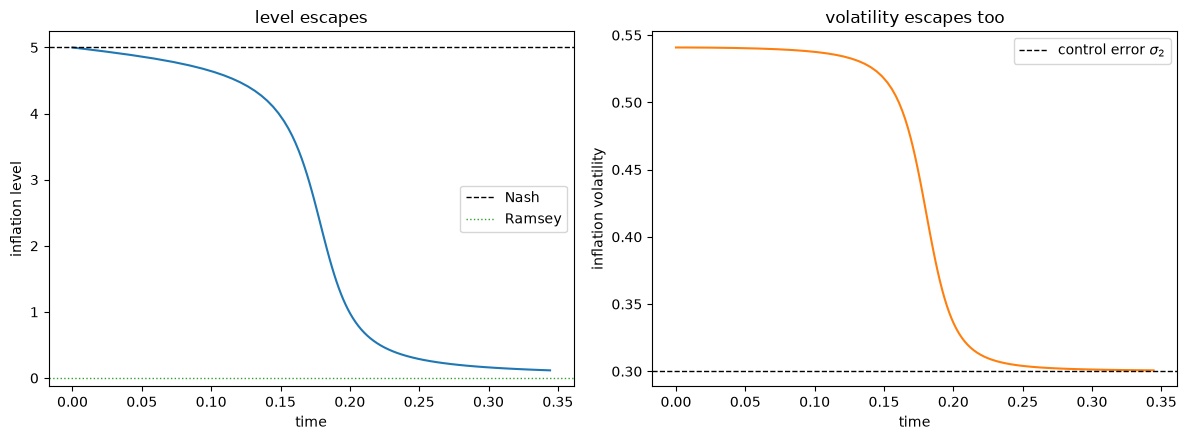

In [11]:
σ3 = 0.9                                   # size of the stabilizable shock
infl_vol = np.sqrt(model.σ2**2 + (slope / (1 + slope**2))**2 * σ3**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(esc.t, infl)
axes[0].axhline(model.θ * model.u, color='k', ls='--', lw=1, label='Nash')
axes[0].axhline(0, color='C2', ls=':', lw=1, label='Ramsey')
axes[0].set_xlabel('time'); axes[0].set_ylabel('inflation level')
axes[0].set_title('level escapes'); axes[0].legend()

axes[1].plot(esc.t, infl_vol, 'C1')
axes[1].axhline(model.σ2, color='k', ls='--', lw=1, label=r'control error $\sigma_2$')
axes[1].set_xlabel('time'); axes[1].set_ylabel('inflation volatility')
axes[1].set_title('volatility escapes too'); axes[1].legend()

plt.tight_layout()
plt.show()

随着信念的逃逸，二者都会下降，因为它们都源自同一个根源：政府对存在可利用权衡取舍的信念。

{cite}`EllisonYates2007` 还就逃逸的*时机*得出了一个更为微妙的进一步结论。

一个更大的可稳定冲击 $\sigma_3$ 会使逃逸*更难触发*：为了制造出通货膨胀在变动而失业率保持不变的假象，一段异常的冲击序列现在不仅要抵消控制误差，还必须抵消政府自身针对 $W_3$ 的稳定化反应。

政府能够抵消的冲击越多，触发逃逸所需的序列就越复杂，等待时间也就越长。

如果按字面理解，这意味着一个经济体恰恰在需要稳定化的冲击*较少*时，才更有可能逃向低通胀——这为二十世纪八十年代中期出现的经济平静与伴随而来的反通胀之间提供了一种颇具启发性的联系。

这同时也是一个关于数据的论断，它指向了本系列讲座压轴的实证内容。

如果经济平静与反通胀是同时到来的，那么一个统计模型必须能够区分*冲击的缩小*与*动态的转变*，才能判断究竟是何者导致了何者。

{doc}`phillips_drifts_volatilities` 构建了一个可以同时容纳这两条渠道的模型，并让数据来判定二者各自的贡献。

## 练习

```{exercise-start}
:label: en_ex1
```

逃逸强制项 {eq}`en_force` 与 $\sigma_1 \sigma_2$——两个冲击标准差的乘积——成比例。

对一组 $\sigma_1 = \sigma_2 = \sigma \in \{0.2, 0.3, 0.4, 0.5\}$ 分别积分主导逃逸常微分方程 {eq}`en_escape`，并报告每种情形下从半径为 5 的圆中*退出的时间*。

一个噪声更大的经济体，会如何影响信念沿逃逸路线移动的速度？

```{exercise-end}
```

```{solution-start} en_ex1
:class: dropdown
```

In [12]:
for σ in [0.2, 0.3, 0.4, 0.5]:
    m = EscapeModel(θ=1.0, u=5.0, σ1=σ, σ2=σ)
    γ0 = np.array([-m.θ, m.u * (1 + m.θ**2)])

    def leave(t, z, m=m, γ0=γ0):
        return 5.0 - np.linalg.norm(z[:2] - γ0)
    leave.terminal = True
    leave.direction = -1

    z0 = np.concatenate([γ0, m.M(γ0).ravel()])
    s = solve_ivp(lambda t, z: escape_ode(t, z, m), [0, 500], z0,
                  events=leave, max_step=0.02, rtol=1e-9, atol=1e-11)
    print(f"σ = {σ}: exit time along the escape path = {s.t[-1]:.2f}")

σ = 0.2: exit time along the escape path = 0.20
σ = 0.3: exit time along the escape path = 0.34
σ = 0.4: exit time along the escape path = 0.50
σ = 0.5: exit time along the escape path = 0.67


更大的 $\sigma$ 会使逃逸强制项 $R^{-1}(\sigma_1\sigma_2, 0)^\top$ 变得更强，因此信念沿逃逸路线移动得更快（沿确定性路径的退出*时间*更短）。

请注意，这与逃逸的*频率*不同，后者由行动值 $\bar S$ 与增益 $\varepsilon$ 支配；一个噪声更大的经济体，一旦逃逸开始，会更快地走完某条既定的逃逸路线。

```{solution-end}
```

```{exercise-start}
:label: en_ex2
```

将向量场图中的强化效应量化。

在逃逸路径*沿途*的若干点上，计算均值动态漂移 $R^{-1}\bar g(\gamma)$，并测量它与当前信念指向拉姆齐信念 $(0, u)$ 方向之间的余弦对齐度。

余弦值接近 $+1$ 意味着均值动态正将信念推*向*拉姆齐——强化了逃逸。

```{exercise-end}
```

```{solution-start} en_ex2
:class: dropdown
```

In [13]:
γ_ramsey = np.array([0.0, model.u])            # Belief 2

def cosine_toward_ramsey(γ, R):
    drift = np.linalg.inv(R) @ model.g_bar(γ)
    to_ramsey = γ_ramsey - γ
    denom = np.linalg.norm(drift) * np.linalg.norm(to_ramsey)
    return np.nan if denom < 1e-9 else drift @ to_ramsey / denom

for frac in [0.0, 0.25, 0.5, 0.75, 0.95]:
    k = min(int(frac * len(esc.t)), len(esc.t) - 1)
    γ, R = esc.y[:2, k], esc.y[2:, k].reshape(2, 2)
    print(f"frac {frac:.2f}:  γ = ({γ[0]:+.2f}, {γ[1]:.1f}),  "
          f"cos(drift, →Ramsey) = {cosine_toward_ramsey(γ, R):+.2f}")

frac 0.00:  γ = (-1.00, 10.0),  cos(drift, →Ramsey) = +nan
frac 0.25:  γ = (-0.65, 8.2),  cos(drift, →Ramsey) = +1.00
frac 0.50:  γ = (-0.23, 6.1),  cos(drift, →Ramsey) = +1.00
frac 0.75:  γ = (-0.07, 5.3),  cos(drift, →Ramsey) = +1.00
frac 0.95:  γ = (-0.03, 5.1),  cos(drift, →Ramsey) = +1.00


正处于自我确认均衡时，漂移为零（余弦值未定义），因此均值动态既不助力也不阻碍逃逸。

但一旦信念沿逃逸路线移动了哪怕一点点，均值动态的漂移方向就几乎精确地指向拉姆齐信念（余弦值 $\approx +1$）：均值动态一路强化逃逸，直至到达拉姆齐水平。

CWS 所强调的对抗力量，仅局限于均衡附近的一个*极小*邻域——逃逸动态只需要将信念推出这个邻域，之后均值动态便会完成剩余的工作。

```{solution-end}
```